# ONNX CPU — FP32 vs INT8 Comparison

Compares the ONNX Runtime CPU **FP32 baseline** against the **INT8 dynamic-quantized** model for BGE-M3,
across the `en`/`th` datasets and a grid of batch sizes and sequence lengths.

Each row is one benchmark run from the stage-breakdown logs. We answer two questions:

1. **Is INT8 faster?** — throughput (tokens/sec) and p95 latency vs FP32.
2. **Is INT8 accurate enough?** — cosine similarity and retrieval overlap vs the FP32 reference, against the gate thresholds recorded in the data.

## Data source configuration

Override paths via environment variables:

- `BGE_RESULTS_DIR` — directory containing the `.jsonl` files (default: `../results`)
- `FP32_FILE` — FP32 filename (default: `onnx_cpu_fp32_stage_breakdown.jsonl`)
- `INT8_FILE` — INT8 filename (default: `onnx_cpu_int8_stage_breakdown.jsonl`)

Language filter: set `LANG_FILTER` to `"en"`, `"th"`, `"mixed"`, or `"all"` (default `"all"`).

In [ ]:
from pathlib import Path
import os

RESULTS = Path(os.environ.get("BGE_RESULTS_DIR", "../results"))
FP32_SUFFIX = os.environ.get("FP32_FILE", "onnx_cpu_fp32_stage_breakdown.jsonl")
INT8_SUFFIX = os.environ.get("INT8_FILE", "onnx_cpu_int8_stage_breakdown.jsonl")
FP32_PATH = RESULTS / FP32_SUFFIX
INT8_PATH = RESULTS / INT8_SUFFIX

LANG_FILTER = "all"   # "en" | "th" | "mixed" | "all"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KEY_COLS = ["dataset", "batch_size", "max_length"]

fp32 = pd.read_json(FP32_PATH, lines=True)
int8 = pd.read_json(INT8_PATH, lines=True)

print(f"FP32 runs: {len(fp32):>3}  ({fp32['precision'].unique().tolist()})")
print(f"INT8 runs: {len(int8):>3}  ({int8['precision'].unique().tolist()})")

fp32_keys = set(map(tuple, fp32[KEY_COLS].itertuples(index=False)))
int8_keys = set(map(tuple, int8[KEY_COLS].itertuples(index=False)))
only_fp32 = sorted(fp32_keys - int8_keys)
only_int8 = sorted(int8_keys - fp32_keys)
if only_fp32:
    print(f"\n[warn] {len(only_fp32)} config(s) only in FP32 (no INT8 counterpart): {only_fp32}")
if only_int8:
    print(f"\n[warn] {len(only_int8)} config(s) only in INT8 (no FP32 counterpart): {only_int8}")
if not only_fp32 and not only_int8:
    print("\nConfig grids match across FP32 and INT8.")

df = pd.concat([fp32, int8], ignore_index=True)

if LANG_FILTER != "all":
    df = df[df["dataset"] == LANG_FILTER].reset_index(drop=True)
    print(f"\n[LANG_FILTER={LANG_FILTER}] -> {len(df)} runs")
else:
    print(f"\n[LANG_FILTER=all] -> {len(df)} runs (datasets: {sorted(df['dataset'].unique())})")


## Hardware & run context

INT8 speedups depend heavily on CPU ISA support. Without AVX-512 VNNI / AMX-INT8, INT8 gains come mainly
from reduced memory bandwidth rather than dedicated integer-matmul instructions.

In [2]:
r = fp32.iloc[0]
print("CPU            :", r["cpu_model_name"])
print(f"cores          : {r['cpu_physical_cores']} physical / {r['cpu_logical_cores']} logical")
isa = [name for name, col in [
    ("AVX", "cpu_has_avx"), ("AVX2", "cpu_has_avx2"), ("AVX-512", "cpu_has_avx512"),
    ("AVX-512 VNNI", "cpu_has_avx512_vnni"), ("AMX-BF16", "cpu_has_amx_bf16"), ("AMX-INT8", "cpu_has_amx_int8"),
] if bool(r.get(col))]
print("ISA (int8-relevant):", ", ".join(isa) if isa else "none")
if not bool(r.get("cpu_has_avx512_vnni")) and not bool(r.get("cpu_has_amx_int8")):
    print("  -> no VNNI/AMX-INT8: INT8 speedup is bandwidth-driven, not from int-matmul acceleration.")
print(f"memory         : {r['memory_total_bytes'] / 1e9:.1f} GB total")
print()
print("datasets       :", sorted(df["dataset"].unique()))
print("batch_size     :", [int(v) for v in sorted(df["batch_size"].unique())])
print("max_length     :", [int(v) for v in sorted(df["max_length"].unique())])
print("model          :", r["model"])

CPU            : AMD Ryzen 7 PRO 6850U with Radeon Graphics
cores          : 8 physical / 16 logical
ISA (int8-relevant): AVX, AVX2
  -> no VNNI/AMX-INT8: INT8 speedup is bandwidth-driven, not from int-matmul acceleration.
memory         : 32.3 GB total

datasets       : ['en', 'th']
batch_size     : [1, 8, 16, 32]
max_length     : [64, 128]
model          : BAAI/bge-m3


## Summary table

In [ ]:
# ── Condensed summary: grouped by (precision, max_length, batch_size), mean across datasets ──
agg = (
    df.groupby(["precision", "max_length", "batch_size"])
    .agg(
        emb_tok_s=("embedding_tokens_per_sec", "mean"),
        e2e_tok_s=("end_to_end_tokens_per_sec", "mean"),
        emb_items_s=("embedding_items_per_sec", "mean"),
        emb_p95_ms=("embedding_latency_ms_p95", "mean"),
    )
    .round(2)
    .reset_index()
)
agg["cfg"] = "bs" + agg["batch_size"].astype(str) + "·L" + agg["max_length"].astype(str)
agg = agg.sort_values(["max_length", "batch_size", "precision"]).reset_index(drop=True)
agg

# Full per-run table (all rows, all columns)
summary_cols = [
    "precision", "dataset", "batch_size", "max_length",
    "embedding_tokens_per_sec", "end_to_end_tokens_per_sec", "embedding_items_per_sec",
    "embedding_latency_ms_p95", "validation_passed",
    "reference_cosine_similarity_mean", "retrieval_top10_overlap",
]
df[summary_cols].sort_values(["precision", "dataset", "max_length", "batch_size"]).reset_index(drop=True)


## Throughput overview — FP32 vs INT8

Three panels, all using mean across datasets for each `(batch_size, max_length)`:

- **Embedding tok/s** — pure ONNX model throughput (the quantization target)
- **End-to-end tok/s** — tokenizer + model, i.e. real pipeline throughput
- **Input embeddings/sec** — how many whole input texts are embedded per second

Faint dots are individual per-dataset runs. Label above each pair is the INT8/FP32 speedup.

Below: **embedding vs end-to-end scatter** (paired runs, color=max_length, marker=dataset, size=batch_size).
Below that: **batch scaling** — throughput + efficiency (tok/s ÷ batch_size) vs batch size.

In [ ]:
# ── Throughput: 3-panel (emb tok/s | e2e tok/s | emb items/s) — FP32 vs INT8 ──
tput = df.copy()
tput["cfg"] = "bs" + tput["batch_size"].astype(str) + "·L" + tput["max_length"].astype(str)

def _cfg_key(c):
    bs = int(c.split("·")[0][2:]); L = int(c.split("L")[1]); return (L, bs)

cfg_order = sorted(tput["cfg"].unique(), key=_cfg_key)
x = np.arange(len(cfg_order)); w = 0.28

PANELS = [
    ("embedding_tokens_per_sec",  "Embedding tok/s"),
    ("end_to_end_tokens_per_sec", "End-to-end tok/s"),
    ("embedding_items_per_sec",    "Input embeddings/sec"),
]
PREC_COLORS = {"fp32": "#3b82f6", "int8": "#f97316"}
PREC_DOTS   = {"fp32": "#1e3a8a", "int8": "#9a3412"}

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharex=True)

for ax, (col, ylabel) in zip(axes, PANELS):
    piv = (tput.groupby(["cfg", "precision"])[col].mean()
                .unstack("precision").reindex(cfg_order))

    for j, prec in enumerate(["fp32", "int8"]):
        if prec not in piv.columns:
            continue
        ax.bar(x + (j - 0.5) * w, piv[prec], w, label=prec.upper(),
               color=PREC_COLORS[prec], edgecolor="white", zorder=3)
        sub = tput[tput["precision"] == prec]
        xi = [cfg_order.index(c) + (j - 0.5) * w for c in sub["cfg"]]
        ax.scatter(xi, sub[col], s=14, color=PREC_DOTS[prec], alpha=0.5,
                   edgecolors="none", zorder=4)

    if "fp32" in piv.columns and "int8" in piv.columns:
        for i, cfg in enumerate(cfg_order):
            f, q = piv.loc[cfg, "fp32"], piv.loc[cfg, "int8"]
            if pd.notna(f) and pd.notna(q) and f:
                ax.text(i, max(f, q) * 1.03, f"{q / f:.2f}×", ha="center",
                        fontsize=8, fontweight="bold", color="#065f46", zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(cfg_order, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(f"{ylabel}  (mean across datasets)")
    ax.set_title(f"{ylabel}", fontsize=12, pad=8)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper left", framealpha=0.9, fontsize=9)

fig.suptitle(
    "BGE-M3 ONNX CPU — Throughput FP32 vs INT8   "
    "bars=mean across datasets · dots=individual runs · label=INT8/FP32 speedup",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


## Embedding vs End-to-end throughput scatter

Each point is one benchmark run. Size = batch_size, Color = max_length, Marker = dataset.
Diagonal dashed line = parity (INT8 = FP32 on both axes). Points above the line: INT8 is faster.

In [ ]:
# ── Scatter: embedding tok/s vs end-to-end tok/s — all runs ──
scatter_df = df.copy()

# If LANG_FILTER is active, annotate the plot
n_fp32 = len(scatter_df[scatter_df["precision"] == "fp32"])
n_int8 = len(scatter_df[scatter_df["precision"] == "int8"])

ML_COLORS   = {64: "#3b82f6", 128: "#f97316"}
DS_MARKERS  = {"en": "o", "th": "s", "mixed": "^"}
BS_MIN, BS_MAX = float(scatter_df["batch_size"].min()), float(scatter_df["batch_size"].max())

fig, ax = plt.subplots(figsize=(10, 8))

for ml in sorted(scatter_df["max_length"].unique()):
    for ds in sorted(scatter_df["dataset"].unique()):
        sub = scatter_df[(scatter_df["max_length"] == ml) & (scatter_df["dataset"] == ds)]
        if sub.empty:
            continue
        x_vals = sub["embedding_tokens_per_sec"]
        y_vals = sub["end_to_end_tokens_per_sec"]
        # normalise batch_size to [30, 180] range for point size
        bs_norm = 30 + 150 * (sub["batch_size"] - BS_MIN) / (BS_MAX - BS_MIN + 1e-9)
        ax.scatter(x_vals, y_vals,
                   s=bs_norm, color=ML_COLORS.get(ml, "gray"),
                   marker=DS_MARKERS.get(ds, "o"), alpha=0.75,
                   edgecolors="white", linewidth=0.5,
                   label=f"L{int(ml)}·{ds}")

# parity line after all scatter points so it draws on top
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", linewidth=1.5, label="parity (x=y)", zorder=2)

ax.set_xlabel("Embedding tok/s", fontsize=11)
ax.set_ylabel("End-to-end tok/s", fontsize=11)
ax.set_title(
    "Embedding tok/s vs End-to-end tok/s\n"
    "(color=max_length, marker=dataset, point size=batch_size)",
    fontsize=12, pad=10
)
ax.grid(alpha=0.3)
ax.legend(title="seq·lang", fontsize=9, framealpha=0.9, loc="upper left")

# size legend
for bs_val in [BS_MIN, BS_MAX]:
    ax.scatter([], [], s=30 + 150 * (bs_val - BS_MIN) / (BS_MAX - BS_MIN + 1e-9),
               color="gray", alpha=0.5,
               label=f"bs={int(bs_val)}")
legend = ax.legend(title="seq·lang | batch size",
                    fontsize=8, framealpha=0.9,
                    loc="upper left", ncol=2)
legend.get_frame().set_linewidth(0.5)

ax.text(0.02, 0.02,
        f"FP32={n_fp32} runs  INT8={n_int8} runs",
        transform=ax.transAxes, fontsize=8, color="gray",
        verticalalignment="bottom")

plt.tight_layout()
plt.show()


## Batch scaling — throughput + efficiency

Top: `embedding_tokens_per_sec` vs batch_size — one line per `(precision, max_length)`.

Bottom: `efficiency = embedding_tokens_per_sec / batch_size` (log y-axis; bs=1 dominates on linear scale).

In [ ]:
# ── Batch scaling: throughput + efficiency (FP32 vs INT8, same chart) ──
batch_vals  = sorted(df["batch_size"].unique())
x_pos       = {b: i for i, b in enumerate(batch_vals)}
max_lengths = sorted(df["max_length"].unique())

PREC_COLOR = {"fp32": "#3b82f6", "int8": "#f97316"}
ML_LINESTYLE = {64: ("-", 2.5), 128: ("--", 2.0)}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for prec in ["fp32", "int8"]:
    for ml in max_lengths:
        sub = df[(df["precision"] == prec) & (df["max_length"] == ml)]
        if sub.empty:
            continue
        med  = sub.groupby("batch_size")["embedding_tokens_per_sec"].median()
        min_v = sub.groupby("batch_size")["embedding_tokens_per_sec"].min()
        max_v = sub.groupby("batch_size")["embedding_tokens_per_sec"].max()
        xs   = [x_pos[b] for b in med.index]
        ls, lw = ML_LINESTYLE.get(ml, ("-", 2))
        color  = PREC_COLOR[prec]
        label  = f"{prec.upper()}·L{ml}"
        axes[0].plot(xs, med.values, marker="o", linestyle=ls, markersize=8,
                      linewidth=lw, color=color, label=label, zorder=5)
        axes[0].fill_between(xs, min_v.values, max_v.values, color=color, alpha=0.12, zorder=3)
        axes[0].scatter([x_pos[b] for b in sub["batch_size"]], sub["embedding_tokens_per_sec"],
                        color=color, alpha=0.20, s=20, edgecolors="none", zorder=3)
        # efficiency
        eff   = med.values / np.array(list(med.index))
        eff_min = min_v.values / np.array(list(min_v.index))
        eff_max = max_v.values / np.array(list(max_v.index))
        axes[1].plot(xs, eff, marker="o", linestyle=ls, markersize=8,
                      linewidth=lw, color=color, label=label, zorder=5)
        axes[1].fill_between(xs, eff_min, eff_max, color=color, alpha=0.12, zorder=3)

axes[0].set_ylabel("Embedding tok/s  (median, min-max band)", fontsize=11)
axes[0].set_title("Batch Scaling — Throughput", fontsize=12, pad=8)
axes[0].grid(alpha=0.3)
axes[0].legend(title="precision·seq_len", fontsize=9, ncol=4, framealpha=0.9)

axes[1].set_ylabel("Efficiency  (tok/s ÷ batch_size, log scale)", fontsize=11)
axes[1].set_yscale("log")
axes[1].set_xlabel("Batch size", fontsize=11)
axes[1].set_title("Batch Scaling — Efficiency", fontsize=12, pad=8)
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(title="precision·seq_len", fontsize=9, ncol=4, framealpha=0.9)

axes[1].set_xticks(list(x_pos.values()))
axes[1].set_xticklabels([f"bs={b}" for b in batch_vals])
axes[1].set_xlim(-0.35, len(batch_vals) - 0.65)

fig.suptitle("BGE-M3 ONNX CPU — Batch Scaling FP32 vs INT8",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Per-input cost — ms/input + inputs/sec

Bar chart grouped by precision (FP32 blue / INT8 orange). Log x-axis for configs,
so the large spread from bs=1 to bs=32 is readable.

In [ ]:
# ── Per-input cost: ms/input + inputs/sec ──
cost = df.copy()
cost["ms_per_input"] = 1000.0 / cost["embedding_items_per_sec"]
cost["inputs_per_sec"]  = cost["embedding_items_per_sec"]
cost["cfg"] = (
    cost["dataset"].astype(str) + "\u00b7bs" + cost["batch_size"].astype(str)
    + "\u00b7L" + cost["max_length"].astype(str)
)

def _cost_key(c):
    parts = c.split("\u00b7")
    return (parts[0], int(parts[2][1:]), int(parts[1][2:]))

cfg_order = sorted(cost["cfg"].unique(), key=_cost_key)

piv_ms  = (cost.groupby(["cfg", "precision"])["ms_per_input"]
           .mean().unstack("precision").reindex(cfg_order))
piv_ips = (cost.groupby(["cfg", "precision"])["inputs_per_sec"]
           .mean().unstack("precision").reindex(cfg_order))

n = len(cfg_order)
PREC_COLORS = {"fp32": "#3b82f6", "int8": "#f97316"}
PREC_ALPHA  = {"fp32": 0.85,      "int8": 0.85}

# ── Bar geometry ─────────────────────────────────────────────────────────────
BW = 0.42
BG = 0.08
BS = 0.22
TOTAL = 2 * BW + BG
OFFSET = -TOTAL / 2

def x_positions():
    return [i * (TOTAL + BS) + OFFSET for i in range(n)]

FP32_X = x_positions()
INT8_X = [x + BW + BG for x in FP32_X]

# ── Language band edges ─────────────────────────────────────────────────────
lang_groups = {}
for c in cfg_order:
    ds = c.split("\u00b7")[0]
    lang_groups.setdefault(ds, []).append(c)

def band_edges(configs):
    lo = cfg_order.index(configs[0])
    hi = cfg_order.index(configs[-1])
    xs = x_positions()
    return xs[lo] - TOTAL / 2, xs[hi] + TOTAL / 2

# ── Figure: 2 subplots sharing y-axis labels ───────────────────────────────
fig, (ax_ms, ax_ips) = plt.subplots(1, 2, figsize=(15, 8))
fig.subplots_adjust(wspace=0.38)

# ── Language bands (shared background) ─────────────────────────────────────
for ds, configs in lang_groups.items():
    lo_x, hi_x = band_edges(configs)
    for ax in (ax_ms, ax_ips):
        ax.axhspan(lo_x - 0.05, hi_x + 0.05, alpha=0.045, color="gray", zorder=0)
    mid = (lo_x + hi_x) / 2
    for ax in (ax_ms, ax_ips):
        ax.text(-0.06, mid, ds, ha="right", va="center",
                fontsize=9, color="gray", style="italic",
                transform=ax.get_yaxis_transform())

# ── ms/input ────────────────────────────────────────────────────────────────
for j, (prec, color) in enumerate([("fp32", PREC_COLORS["fp32"]),
                                    ("int8",  PREC_COLORS["int8"])]):
    if prec not in piv_ms.columns:
        continue
    xs = FP32_X if prec == "fp32" else INT8_X
    bars = ax_ms.barh(xs, piv_ms[prec].values, BW,
                      color=color, alpha=PREC_ALPHA[prec],
                      edgecolor="white", zorder=3)
    ax_ms.bar_label(bars, fmt="%.1f", fontsize=7.5, padding=2, label_type="center")

ax_ms.set_yticks(x_positions())
ax_ms.set_yticklabels(cfg_order, fontsize=8.5)
ax_ms.set_xlabel("ms / input (log scale)", fontsize=10)
ax_ms.set_xscale("log")
ax_ms.set_title("Per-Input Cost\n(lower = better)", fontsize=11, pad=6)
ax_ms.grid(axis="x", alpha=0.25, zorder=0)
ax_ms.legend(framealpha=0.9, fontsize=9, loc="lower right")

# ── inputs/sec ────────────────────────────────────────────────────────────────
for j, (prec, color) in enumerate([("fp32", PREC_COLORS["fp32"]),
                                    ("int8",  PREC_COLORS["int8"])]):
    if prec not in piv_ips.columns:
        continue
    xs = FP32_X if prec == "fp32" else INT8_X
    bars = ax_ips.barh(xs, piv_ips[prec].values, BW,
 color=color, alpha=PREC_ALPHA[prec],
                       edgecolor="white", zorder=3)
    ax_ips.bar_label(bars, fmt="%.0f", fontsize=7.5, padding=2, label_type="center")

ax_ips.set_yticks(x_positions())
ax_ips.set_yticklabels(cfg_order, fontsize=8.5)
ax_ips.set_xlabel("Inputs / sec", fontsize=10)
ax_ips.set_title("Throughput\n(higher = better)", fontsize=11, pad=6)
ax_ips.grid(axis="x", alpha=0.25, zorder=0)
ax_ips.legend(framealpha=0.9, fontsize=9, loc="lower right")

ax_ms.set_ylabel("Configuration  (dataset\u00b7bs\u00b7L)", fontsize=9)

fig.suptitle(
    "BGE-M3 ONNX CPU \u2014 Per-Input Cost  FP32 vs INT8",
    fontsize=13, fontweight="bold"
)
plt.show()


## Speedup table — full + summary

Full per-run speedup table (INT8 / FP32 ratios) sorted by embedding speedup.
Summary below shows mean/min/max speedup grouped by `(dataset, max_length)`.

In [ ]:
# ── Speedup table (merged full + summary) ──
speed_cols   = ["embedding_tokens_per_sec", "end_to_end_tokens_per_sec", "embedding_latency_ms_p95"]
quality_cols = ["validation_passed", "reference_cosine_similarity_mean",
               "reference_cosine_similarity_min", "retrieval_top10_overlap"]

fp32 = fp32.drop_duplicates(subset=KEY_COLS, keep="last")
int8 = int8.drop_duplicates(subset=KEY_COLS, keep="last")

fp32_s = fp32[KEY_COLS + speed_cols].add_prefix("fp32_").rename(columns={f"fp32_{k}": k for k in KEY_COLS})
int8_s = int8[KEY_COLS + speed_cols + quality_cols].add_prefix("int8_").rename(columns={f"int8_{k}": k for k in KEY_COLS})

cmp_df = fp32_s.merge(int8_s, on=KEY_COLS, how="inner")

cmp_df["embedding_speedup"]  = cmp_df["int8_embedding_tokens_per_sec"] / cmp_df["fp32_embedding_tokens_per_sec"]
cmp_df["e2e_speedup"]        = cmp_df["int8_end_to_end_tokens_per_sec"] / cmp_df["fp32_end_to_end_tokens_per_sec"]
cmp_df["p95_latency_ratio"] = cmp_df["int8_embedding_latency_ms_p95"] / cmp_df["fp32_embedding_latency_ms_p95"]

cmp_df["run"] = (
    cmp_df["dataset"].astype(str) + " bs=" + cmp_df["batch_size"].astype(str)
    + " len=" + cmp_df["max_length"].astype(str)
)

print(f"Matched runs: {len(cmp_df)}")

view_cols   = ["run", "embedding_speedup", "e2e_speedup", "p95_latency_ratio", "int8_validation_passed"]
display_df  = cmp_df[view_cols].sort_values("embedding_speedup", ascending=False).round(3).reset_index(drop=True)
print("\n── Speedup table (sorted by embedding_speedup desc) ──")
display_df

speedup_summary = (
    cmp_df.groupby(["dataset", "max_length"])
    .agg(
        emb_speedup_mean=("embedding_speedup", "mean"),
        emb_speedup_min=("embedding_speedup", "min"),
        emb_speedup_max=("embedding_speedup", "max"),
        e2e_speedup_mean=("e2e_speedup", "mean"),
        p95_latency_ratio_mean=("p95_latency_ratio", "mean"),
        validation_pass_rate=("int8_validation_passed", "mean"),
        runs=("embedding_speedup", "size"),
    )
    .round(3)
)
print("\n── Speedup summary by (dataset, max_length) ──")
speedup_summary


## Plot — p95 embedding latency (FP32 vs INT8)

Absolute latency, so the practical win is visible rather than a ratio.

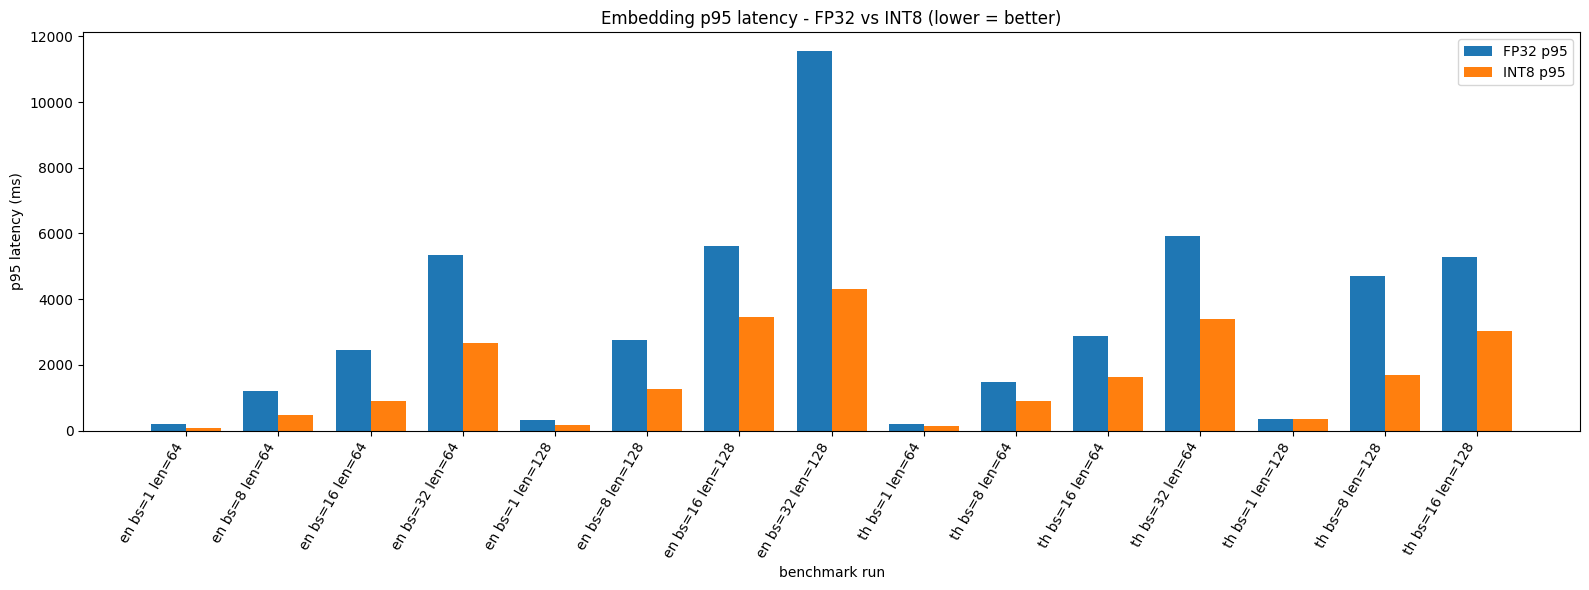

In [6]:
lat = cmp_df.sort_values(["dataset", "max_length", "batch_size"]).copy()
x = np.arange(len(lat))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w / 2, lat["fp32_embedding_latency_ms_p95"], w, label="FP32 p95")
ax.bar(x + w / 2, lat["int8_embedding_latency_ms_p95"], w, label="INT8 p95")
ax.set_title("Embedding p95 latency - FP32 vs INT8 (lower = better)")
ax.set_xlabel("benchmark run")
ax.set_ylabel("p95 latency (ms)")
ax.set_xticks(x)
ax.set_xticklabels(lat["run"], rotation=60, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Quality vs gate thresholds

Quality is validated against the FP32 reference and is a **model-level** property — it does not depend on
batch size or sequence length, so every INT8 run reports the same scores. We therefore show the achieved
values once, against the thresholds recorded in the data.

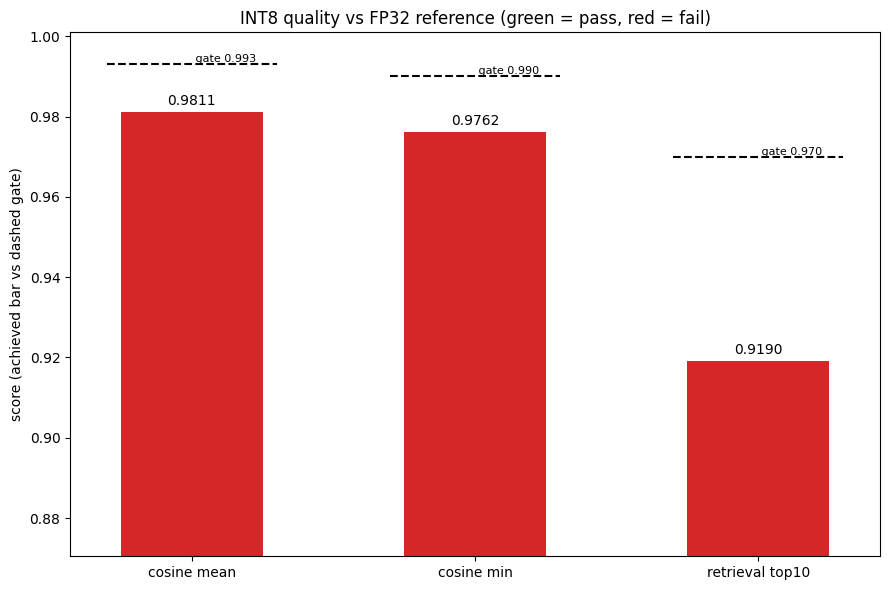

cosine mean      achieved=0.9811  gate>=0.993  FAIL (short by 0.0119)
cosine min       achieved=0.9762  gate>=0.990  FAIL (short by 0.0138)
retrieval top10  achieved=0.9190  gate>=0.970  FAIL (short by 0.0510)


In [7]:
q = int8.iloc[0]
# min-cosine gate is not stored as a column; recover it from the validation error text if present.
cos_min_thr = 0.99
for msg in (q.get("reference_validation_errors") or []):
    if "_min too low" in msg and "<" in msg:
        cos_min_thr = float(msg.rsplit("<", 1)[1])

metrics = [
    ("cosine mean", q["reference_cosine_similarity_mean"], q["reference_cosine_similarity_threshold"]),
    ("cosine min", q["reference_cosine_similarity_min"], cos_min_thr),
    ("retrieval top10", q["retrieval_top10_overlap"], q["retrieval_top10_overlap_threshold"]),
]
names = [m[0] for m in metrics]
achieved = [m[1] for m in metrics]
required = [m[2] for m in metrics]
passed = [a >= t for a, t in zip(achieved, required)]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(x, achieved, 0.5, color=["tab:green" if p else "tab:red" for p in passed])
ax.bar_label(bars, fmt="%.4f", padding=3)
for xi, t in zip(x, required):
    ax.hlines(t, xi - 0.3, xi + 0.3, color="black", linestyle="--", linewidth=1.5)
    ax.text(xi, t, f" gate {t:.3f}", va="bottom", ha="left", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names)
lo = min(achieved + required)
ax.set_ylim(lo - (1 - lo) * 0.6, 1.001)
ax.set_ylabel("score (achieved bar vs dashed gate)")
ax.set_title("INT8 quality vs FP32 reference (green = pass, red = fail)")
plt.tight_layout()
plt.show()

for name, a, t, p in zip(names, achieved, required, passed):
    status = "PASS" if p else f"FAIL (short by {t - a:.4f})"
    print(f"{name:<16} achieved={a:.4f}  gate>={t:.3f}  {status}")

## Failed INT8 runs

Runs where `validation_passed` is not `True`, with the specific gate failures.

In [8]:
failed_int8 = int8[int8["validation_passed"] != True]

failed_cols = [
    "dataset", "batch_size", "max_length",
    "reference_cosine_similarity_mean", "reference_cosine_similarity_min",
    "retrieval_top10_overlap",
    "embedding_nan_count", "embedding_inf_count",
    "validation_errors",
]

print(f"{len(failed_int8)} of {len(int8)} INT8 runs failed validation.")
failed_int8[failed_cols].reset_index(drop=True)

15 of 15 INT8 runs failed validation.


,dataset,batch_size,max_length,reference_cosine_similarity_mean,reference_cosine_similarity_min,retrieval_top10_overlap,embedding_nan_count,embedding_inf_count,validation_errors
0,en,1,64,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
1,en,1,128,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
2,en,8,64,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
3,en,8,128,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
4,en,16,64,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
5,en,16,128,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
6,en,32,64,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
7,en,32,128,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
8,th,1,64,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...
9,th,1,128,0.981083,0.976244,0.919048,0,0,[reference_cosine_similarity_mean too low: 0.9...


## Decision summary

Decision needs **both** a meaningful speedup (> +10%) **and** a passing quality gate. We report each axis
separately so a near-miss on quality is not hidden by a binary pass/fail.

In [10]:
SPEEDUP_MIN = 1.10

fast = cmp_df["embedding_speedup"] > SPEEDUP_MIN
ok = cmp_df["int8_validation_passed"] == True

accepted = cmp_df[fast & ok]
fast_only = cmp_df[fast & ~ok]
accurate_only = cmp_df[~fast & ok]
neither = cmp_df[~fast & ~ok]

print(f"Runs evaluated                      : {len(cmp_df)}")
print(f"  accepted (fast AND accurate)      : {len(accepted)}")
print(f"  fast but FAILS quality gate       : {len(fast_only)}")
print(f"  accurate but not faster than +10% : {len(accurate_only)}")
print(f"  neither                           : {len(neither)}")
print()
print(f"Embedding speedup : mean {cmp_df['embedding_speedup'].mean():.2f}x, "
      f"range {cmp_df['embedding_speedup'].min():.2f}x-{cmp_df['embedding_speedup'].max():.2f}x")
print(f"End-to-end speedup: mean {cmp_df['e2e_speedup'].mean():.2f}x, "
      f"range {cmp_df['e2e_speedup'].min():.2f}x-{cmp_df['e2e_speedup'].max():.2f}x")
print()

if len(accepted) == 0 and len(fast_only) == len(cmp_df):
    q = int8.iloc[0]
    print("VERDICT: INT8 is consistently faster but is REJECTED on quality across every run.")
    print(f"  cosine mean {q['reference_cosine_similarity_mean']:.4f} < gate {q['reference_cosine_similarity_threshold']:.3f}")
    print(f"  retrieval top10 {q['retrieval_top10_overlap']:.4f} < gate {q['retrieval_top10_overlap_threshold']:.3f}")
    print("  Next steps: try per-channel / static quantization, or exclude sensitive ops from quantization.")
elif len(accepted) == len(cmp_df):
    print("VERDICT: INT8 accepted on all runs (fast and within quality gates).")
else:
    print("VERDICT: mixed - see per-bucket counts above.")
    if len(accepted):
        print("\nAccepted configurations:")
        print(accepted[["run", "embedding_speedup", "int8_reference_cosine_similarity_mean", "int8_retrieval_top10_overlap"]].to_string(index=False))

Runs evaluated                      : 15
  accepted (fast AND accurate)      : 0
  fast but FAILS quality gate       : 15
  accurate but not faster than +10% : 0
  neither                           : 0

Embedding speedup : mean 1.92x, range 1.27x-2.94x
End-to-end speedup: mean 1.83x, range 1.38x-2.27x

VERDICT: INT8 is consistently faster but is REJECTED on quality across every run.
  cosine mean 0.9811 < gate 0.993
  retrieval top10 0.9190 < gate 0.970
  Next steps: try per-channel / static quantization, or exclude sensitive ops from quantization.


## Export comparison CSV

In [11]:
out = RESULTS / "onnx_cpu_fp32_vs_int8.csv"
cmp_df.to_csv(out, index=False)
print(f"Wrote {len(cmp_df)} rows to {out}")
out

Wrote 15 rows to ../results/onnx_cpu_fp32_vs_int8.csv


PosixPath('../results/onnx_cpu_fp32_vs_int8.csv')